# **NLU Assignment-2**

---



## **PROBLEM 1: LEARNING WORD EMBEDDINGS FROM IIT JODHPUR DATA**

### **TASK-1: DATASET PREPARATION**



In [ ]:
import os
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

!pip install pdfplumber beautifulsoup4 nltk wordcloud

import pdfplumber
import requests
from bs4 import BeautifulSoup
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

STEP 1: DATA COLLECTION\
Collect textual data from multiple sources:
* Website pages : Academic Regulation and CSE department, ME department
* PDFs : Attendance Policy circular, Examination Policy Circular


In [ ]:
# website pages
urls = [
    "https://iitj.ac.in/computer-science-engineering/",
    "https://iitj.ac.in/mechanical-engineering/",
    "https://iitj.ac.in/office-of-academics/en/academic-regulations#Academic%20Regulations"
]

corpus = ""
document_count = 0   # (Used later for reporting total number of documents)

# Extract text from PDFs
pdf_files = [f for f in os.listdir() if f.endswith(".pdf")]

print("Found PDFs:", pdf_files)

for file in pdf_files:
    try:
        document_count += 1
        with pdfplumber.open(file) as pdf:
            for page in pdf.pages:
                text = page.extract_text()
                if text:
                    corpus += text + "\n"
    except Exception as e:
        print(f"Error reading {file}:", e)

# Extract text from websites
for url in urls:
    try:
        response = requests.get(url, timeout=10)
        soup = BeautifulSoup(response.text, "html.parser")

        # Remove scripts and styles
        for tag in soup(["script", "style"]):
            tag.decompose()

        text = soup.get_text(separator=" ")
        corpus += text + "\n"
        document_count += 1

    except Exception as e:
        print("Failed to fetch:", url)

#  Save raw corpus
with open("raw_corpus.txt", "w", encoding="utf-8") as f:
    f.write(corpus)

print("\nRaw corpus created!")
print("Total documents collected:", document_count)

Found PDFs: ['Academic_Regulations_Final_03_09_2019.pdf', '7.1_Circular_51Circular-No.-IITJOAACircular2024-2551682-dated-08-July-2024.pdf', '7.2_Circular_52Circular-No.-IITJOAACircular2024-2552683-dated-08-July-2024.pdf']

Raw corpus created!
Total documents collected: 6


STEP 2: PREPROCESSING


In [ ]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# download stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

with open("raw_corpus.txt", encoding="utf-8") as f:
    text = f.read()

# Lowercase
text = text.lower()

# Normalize degree names
text = re.sub(r"\bb[\.\-\s]*tech\b", "btech", text)
text = re.sub(r"\bm[\.\-\s]*tech\b", "mtech", text)
text = re.sub(r"\bb[\.\-\s]*sc\b", "bsc", text)
text = re.sub(r"\bm[\.\-\s]*sc\b", "msc", text)
text = re.sub(r"\bph[\.\-\s]*d\b", "phd", text)

# Removes patterns like: ###147852369$$$_RedirectToLoginPage_%%%963258741!!!
text = re.sub(r"#+.*?\$\$\$.*?%%%.*?!+", " ", text)

# Remove navigation/boilerplate words
text = re.sub(
    r"(redirecttologinpage|redirectto page|play arrow|play_arrow|previous next|previous|next|"
    r"view all|highlights?|announcements?|news|events|"
    r"home|people|academics?|alumni|placements?|"
    r"important links?|contact|feedback|intranet|portal|repository|"
    r"recruitment|tenders?|nirf|committee|"
    r"copyright|all rights reserved|last updated|"
    r"arrow_downward|"
    r"back to index|index|table|section|sitemap|"
    r"download file|file|pdf)",
    " ",
    text
)

# Keep only alphabets and sentence separators
text = re.sub(r"[^a-z\. ]", " ", text)

# Remove extra spaces
text = re.sub(r"\s+", " ", text)

# Split into sentences
sentences = text.split(".")

clean_sentences = []

for s in sentences:
    words = word_tokenize(s)

    # Remove short words + stopwords
    words = [w for w in words if len(w) > 2 and w not in stop_words]

    # Keep meaningful sentences
    if len(words) >= 6:
        clean_sentences.append(" ".join(words))

# Final cleaned text
clean_text = ". ".join(clean_sentences)

# Save cleaned corpus
with open(f"{OUTPUT_DIR}/clean_corpus.txt", "w", encoding="utf-8") as f:
    f.write(clean_text)

print("Clean corpus ready!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Clean corpus ready!


STEP 3: TOKENIZATION

In [ ]:
tokens = word_tokenize(clean_text)

STEP 4: DATASET STATISTICS

In [ ]:
total_tokens = len(tokens)
vocab = set(tokens)
vocab_size = len(vocab)

print("DATASET STATISTICS")
print("Total documents:", document_count)
print("Total tokens:", total_tokens)
print("Vocabulary size:", vocab_size)

DATASET STATISTICS
Total documents: 6
Total tokens: 16570
Vocabulary size: 1749


STEP 5: WORD CLOUD

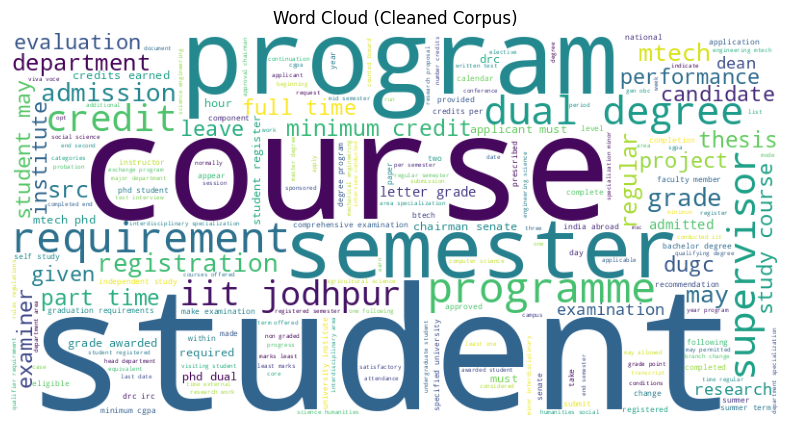

In [ ]:
#Visualizing most frequent words

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud (Cleaned Corpus)")

plt.savefig(f"{OUTPUT_DIR}/wordcloud.png", bbox_inches='tight')
plt.show()


### **TASK-2: MODEL TRAINING**

STEP 1: LOAD CLEAN CORPUS

In [ ]:
# loading cleaned corpus from Task-1
with open(f"{OUTPUT_DIR}/clean_corpus.txt", encoding="utf-8") as f:
    text = f.read()

# breaking text into sentences (Word2Vec learns from sentence context)
raw_sentences = text.split(".")

sentences = []

for s in raw_sentences:
    words = s.strip().split()

    # keeping only useful sentences (avoids noise)
    if len(words) >= 6:
        sentences.append(words)

print("Total sentences used:", len(sentences))
print("Sample sentence:", sentences[0][:10])

Total sentences used: 1218
Sample sentence: ['programmes', 'rules', 'regulations', 'students', 'enrolled', 'july', 'onwards', 'indian', 'institute', 'technology']


STEP 2: TRAIN USING GENSIM (CBOW + SKIP-GRAM)

In [ ]:
!pip install gensim

from gensim.models import Word2Vec
import itertools
import pandas as pd

# trying different combinations of parameters
embedding_dims = [50, 100]
window_sizes = [3, 5]
negative_samples = [5, 10]

# storing results so we can compare later
results = []

for dim, window, neg in itertools.product(embedding_dims, window_sizes, negative_samples):

    print(f"\nTraining CBOW → dim={dim}, window={window}, neg={neg}")

    # training CBOW model (predicts target from context)
    cbow_model = Word2Vec(
        sentences=sentences,
        vector_size=dim,
        window=window,
        sg=0,
        negative=neg,
        min_count=2,
        epochs=10
    )

    # Collect results for CBOW model
    for word in ["student", "research", "phd", "exam"]:
        if word in cbow_model.wv:
            for n, s in cbow_model.wv.most_similar(word, topn=5):
                results.append({
                    "Model": "CBOW",
                    "Word": word,
                    "Neighbor": n,
                    "Score": s,
                    "Dim": dim,
                    "Window": window,
                    "Neg": neg
                })

    print(f"Training Skip-gram → dim={dim}, window={window}, neg={neg}")

    # training Skip-gram model (predicts context from target)
    sg_model = Word2Vec(
        sentences=sentences,
        vector_size=dim,
        window=window,
        sg=1,
        negative=neg,
        min_count=2,
        epochs=10
    )

    # Collect results for Skip-gram model
    for word in ["student", "research", "phd", "exam"]:
        if word in sg_model.wv:
            for n, s in sg_model.wv.most_similar(word, topn=5):
                results.append({
                    "Model": "SkipGram",
                    "Word": word,
                    "Neighbor": n,
                    "Score": s,
                    "Dim": dim,
                    "Window": window,
                    "Neg": neg
                })

df = pd.DataFrame(results)
df.to_csv("output/word2vec_results.csv", index=False)

print("\nAll models trained and results saved!")


Training CBOW → dim=50, window=3, neg=5
Training Skip-gram → dim=50, window=3, neg=5

Training CBOW → dim=50, window=3, neg=10
Training Skip-gram → dim=50, window=3, neg=10

Training CBOW → dim=50, window=5, neg=5
Training Skip-gram → dim=50, window=5, neg=5

Training CBOW → dim=50, window=5, neg=10
Training Skip-gram → dim=50, window=5, neg=10

Training CBOW → dim=100, window=3, neg=5
Training Skip-gram → dim=100, window=3, neg=5

Training CBOW → dim=100, window=3, neg=10
Training Skip-gram → dim=100, window=3, neg=10

Training CBOW → dim=100, window=5, neg=5
Training Skip-gram → dim=100, window=5, neg=5

Training CBOW → dim=100, window=5, neg=10
Training Skip-gram → dim=100, window=5, neg=10

All models trained and results saved!


STEP 3: **FROM-SCRATCH** WORD2VEC

In [ ]:
# Build vocabulary

import numpy as np
from collections import Counter

# flattening all words into one list
all_words = [word for sentence in sentences for word in sentence]

# counting word frequencies
word_counts = Counter(all_words)

# creating vocab and mappings
vocab = list(word_counts.keys())
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)

Vocabulary size: 1748


In [ ]:
# Initialize embeddings

embedding_dim = 50

# initializing input and output matrices randomly
W_in = np.random.randn(vocab_size, embedding_dim) * 0.01
W_out = np.random.randn(vocab_size, embedding_dim) * 0.01

In [ ]:
# sigmoid function used for probability calculation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [ ]:
# Create training pairs

window_size = 2
pairs = []

# creating (target, context) pairs from sentences
for sentence in sentences:
    for i, target in enumerate(sentence):
        target_idx = word2idx[target]

        # looking at nearby words (context window)
        for j in range(max(0, i - window_size), min(len(sentence), i + window_size + 1)):
            if i != j:
                context = sentence[j]
                pairs.append((target_idx, word2idx[context]))

print("Total training pairs:", len(pairs))

Total training pairs: 54104


In [ ]:
# Training loop (negative sampling)

epochs = 2
lr = 0.025
neg_samples = 5

for epoch in range(epochs):
    total_loss = 0

    for target, context in pairs:

        v_t = W_in[target]
        v_c = W_out[context]

        # positive example (real context word)
        score = sigmoid(np.dot(v_t, v_c))
        loss = -np.log(score + 1e-9)

        grad = (score - 1)
        W_in[target] -= lr * grad * v_c
        W_out[context] -= lr * grad * v_t

        # negative samples (random wrong words)
        for _ in range(neg_samples):
            neg = np.random.randint(0, vocab_size)

            # avoid picking the same word
            if neg == context:
                continue

            v_n = W_out[neg]
            score_neg = sigmoid(np.dot(v_t, v_n))
            loss -= np.log(1 - score_neg + 1e-9)

            grad_neg = score_neg
            W_in[target] -= lr * grad_neg * v_n
            W_out[neg] -= lr * grad_neg * v_t

        total_loss += loss

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 223727.1932
Epoch 2, Loss: 166587.0457


In [ ]:
# Nearest neighbors (scratch model)

# cosine similarity to measure closeness between words
def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# get embedding of a word
def get_vector(word):
    return W_in[word2idx[word]]

# find similar words
def nearest_neighbors(word, topn=5):
    if word not in word2idx:
        return []

    vec = get_vector(word)

    sims = []
    for w in vocab:
        if w == word:
            continue
        sim = cosine_similarity(vec, get_vector(w))
        sims.append((w, sim))

    sims.sort(key=lambda x: x[1], reverse=True)
    return sims[:topn]


results_text = []

target_words = ["student"]

for word in target_words:
    results_text.append(f"\nWord: {word}")

    neighbors = nearest_neighbors(word)

    if not neighbors:
        results_text.append("Not found in vocabulary\n")
        continue

    for i, (w, sim) in enumerate(neighbors, 1):
        results_text.append(f"{i}. {w} (similarity: {sim:.4f})")

print("\n".join(results_text))


Word: student
1. categories (similarity: 0.9962)
2. also (similarity: 0.9961)
3. registration (similarity: 0.9960)
4. medical (similarity: 0.9959)
5. continuation (similarity: 0.9959)


STEP 4: SAVE FINAL MODEL

In [ ]:
# training a final model using best parameters
final_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    sg=1,
    negative=10,
    min_count=2,
    epochs=10
)

# saving final model so we can reuse it in Task-3
final_model.save(f"{OUTPUT_DIR}/final_word2vec.model")

print("Final model saved!")

Final model saved!


### **TASK-3: SEMANTIC ANALYSIS**

In [ ]:
# loading the trained model from Task-2
model = Word2Vec.load(f"{OUTPUT_DIR}/final_word2vec.model")

print("Model loaded successfully!")

Model loaded successfully!


STEP 1: NEAREST NEIGHBORS (COSINE SIMILARITY)

In [ ]:
target_words = ["research", "student", "phd", "exam", "examination"]

neighbor_lines = []
neighbor_lines.append("NEAREST NEIGHBORS (COSINE SIMILARITY)\n")

for word in target_words:
    if word in model.wv:
        header = f"\nWord: {word}"
        print(header)
        neighbor_lines.append(header)

        neighbors = model.wv.most_similar(word, topn=5)

        for i, (w, s) in enumerate(neighbors, 1):
            line = f"{i}. {w:<15} similarity: {s:.4f}"
            print(line)
            neighbor_lines.append(line)
    else:
        line = f"\nWord: {word} → Not in vocabulary"
        print(line)
        neighbor_lines.append(line)

# Save file
with open("output/semantic_neighbors.txt", "w") as f:
    f.write("\n".join(neighbor_lines))

print("\nNearest neighbors saved to output/semantic_neighbors.txt")


Word: research
1. proposal        similarity: 0.9263
2. areas           similarity: 0.8746
3. projects        similarity: 0.8700
4. art             similarity: 0.8669
5. state           similarity: 0.8646

Word: student
1. eligible        similarity: 0.9144
2. conditions      similarity: 0.9138
3. fine            similarity: 0.9107
4. payment         similarity: 0.9092
5. otherwise       similarity: 0.9035

Word: phd
1. system          similarity: 0.9607
2. mtech           similarity: 0.9523
3. dual            similarity: 0.9394
4. thermofluids    similarity: 0.9297
5. cyber           similarity: 0.9294

Word: exam
1. guardian        similarity: 0.9971
2. quiz            similarity: 0.9970
3. peers           similarity: 0.9970
4. staying         similarity: 0.9967
5. prorating       similarity: 0.9967

Word: examination
1. comprehensive   similarity: 0.9596
2. evaluation      similarity: 0.8909
3. viva            similarity: 0.8866
4. voce            similarity: 0.8845
5. papers      

STEP 2: ANALOGY EXPERIMENTS

In [ ]:
print("\nANALOGY EXPERIMENTS\n")

analogy_lines = []
analogy_lines.append("ANALOGY RESULTS")

def run_analogy(pos, neg, desc):
    try:
        print(desc)
        analogy_lines.append(f"\n{desc}")

        results = model.wv.most_similar(positive=pos, negative=neg, topn=3)

        for w, s in results:
            line = f"{w:<15} score: {s:.4f}"
            print(line)
            analogy_lines.append(line)
        print()

    except:
        line = f"{desc} → skipped (missing words)"
        print(line)
        analogy_lines.append(line)


# analogies
run_analogy(
    pos=["mtech", "btech"],
    neg=["undergraduate"],
    desc="BTech : UG :: MTech : ?"
)

run_analogy(
    pos=["research", "examination"],
    neg=["student"],
    desc="Student : Exam :: Research : ?"
)

run_analogy(
    pos=["phd", "research"],
    neg=["student"],
    desc="Student : Research :: PhD : ?"
)

# Save file
with open("output/analogy_results.txt", "w") as f:
    f.write("\n".join(analogy_lines))

print("\nAnalogy results saved to output/analogy_results.txt")


ANALOGY EXPERIMENTS

BTech : UG :: MTech : ?
degree          score: 0.9029
dual            score: 0.8812
things          score: 0.8653

Student : Exam :: Research : ?
consist         score: 0.7501
comprehensive   score: 0.7253
entrepreneurship score: 0.7220

Student : Research :: PhD : ?
computer        score: 0.8513
mechanical      score: 0.8396
engineering     score: 0.8324


Analogy results saved to output/analogy_results.txt


### **TASK-4: VISUALIZATION**

STEP 1: LOAD MODELS

In [ ]:
# loading models (CBOW + Skip-gram)
cbow_model = Word2Vec.load(f"{OUTPUT_DIR}/final_word2vec.model")
print("Model loaded!")

Model loaded!


STEP 2: SELECT WORDS TO VISUALIZE

In [ ]:
# selecting words for visualization
words = [
    "student", "research", "phd", "exam",
    "btech", "mtech", "course", "project",
    "faculty", "department", "engineering",
    "mechanical", "computer"
]

# keeping only words present in vocabulary
words = [w for w in words if w in cbow_model.wv]

print("Words used:", words)

Words used: ['student', 'research', 'phd', 'exam', 'btech', 'mtech', 'course', 'project', 'faculty', 'department', 'engineering', 'mechanical', 'computer']


STEP 3: GET WORD VECTORS

In [ ]:
vectors = np.array([cbow_model.wv[w] for w in words])

STEP 4: PCA VISUALIZATION

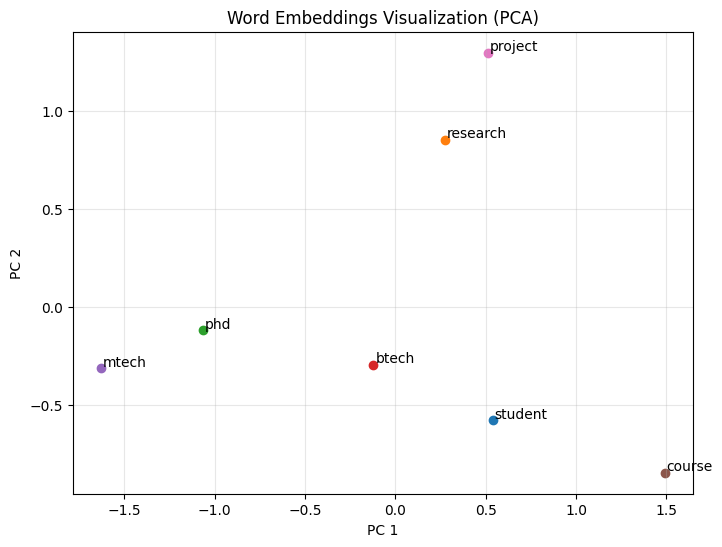

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

# reducing dimensions to 2D using PCA
words = ["student","research","phd","btech","mtech","course","project"]
words = [w for w in words if w in model.wv]

vectors = np.array([model.wv[w] for w in words])

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("Word Embeddings Visualization (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True, alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/pca_plot.png", bbox_inches='tight')
plt.show()

STEP 5: t-SNE VISUALIZATION (BETTER CLUSTERS)

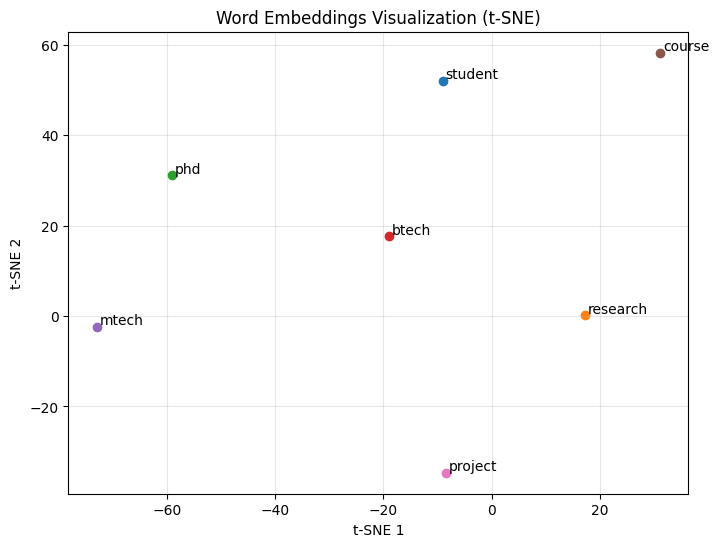

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_tsne = tsne.fit_transform(vectors)

plt.figure(figsize=(8,6))

for i, word in enumerate(words):
    x, y = reduced_tsne[i]
    plt.scatter(x, y)
    plt.text(x+0.5, y+0.5, word)

plt.title("Word Embeddings Visualization (t-SNE)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, alpha=0.3)

plt.savefig(f"{OUTPUT_DIR}/tsne_plot.png", bbox_inches='tight')
plt.show()